## pyRootHair Paper Plots
### Author: Ian Tsang

### Imports

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
import numpy as np
import imageio.v3 as iio
import json

from statsmodels.nonparametric.smoothers_lowess import lowess
from skimage.color import rgb2gray
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from scipy.stats import linregress
from scipy.stats import linregress
from matplotlib.gridspec import GridSpec
from typing import Tuple


plt.style.use(['science', 'no-latex'])


### Figure 1,3,5,6 - Trait Boxplots

In [67]:
plt.rcParams['font.size'] = 16

summary_data = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_1_3_5_6/all_summary.csv')
summary_data['Batch_ID'] = summary_data['Batch_ID'].str.title()
summary_data.sort_values(['Batch_ID'], ascending=True, inplace=True)
labels = list(summary_data['Batch_ID'].unique())

def plot_traits(ncols:int, nrows:int, figsize:Tuple, traits:list, labs:list, ylabs:list):
    
    _, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    
    for trait, axs, lab, ylab in zip(traits, ax.flatten(), labs, ylabs):
        sns.boxplot(summary_data, x='Batch_ID', y=trait, hue='Batch_ID', palette='viridis', legend=False, ax=axs)
        sns.stripplot(summary_data, x='Batch_ID', y=trait, hue='Batch_ID',palette='viridis',edgecolor='black',linewidth=0.8,size=8,legend=False,alpha=0.6,ax=axs)

        axs.set_xlabel('')
        axs.set_xticks(labels)
        axs.set_ylabel(ylab)
        axs.set_xticklabels(labels, rotation=45, ha='right', rotation_mode='anchor', fontsize=13) 
        axs.text(0.03, 0.95, lab, va='top', transform=axs.transAxes, fontsize=20, weight='bold')

    plt.tight_layout()

Figure 1 - Root Hair Traits

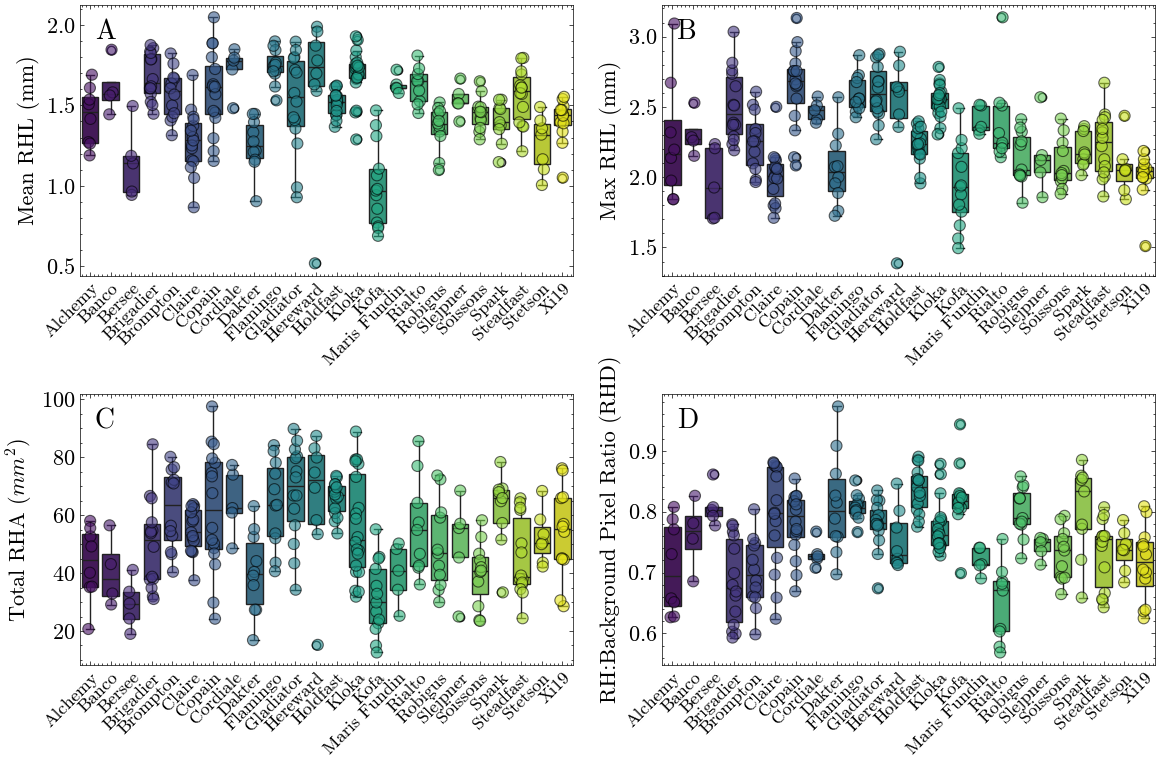

In [68]:
plot_traits(ncols=2,nrows=2,
            figsize=(12,8), 
            traits=['Avg RHL (mm)', 'Max RHL (mm)', 'Total RHA (mm2)', 'RH:Background Pixel Ratio'], 
            labs=['A','B','C','D'],
            ylabs=['Mean RHL (mm)', 'Max RHL (mm)', r'Total RHA ($mm^{2}$)', 'RH:Background Pixel Ratio (RHD)'])

Figure 3 - Root Traits


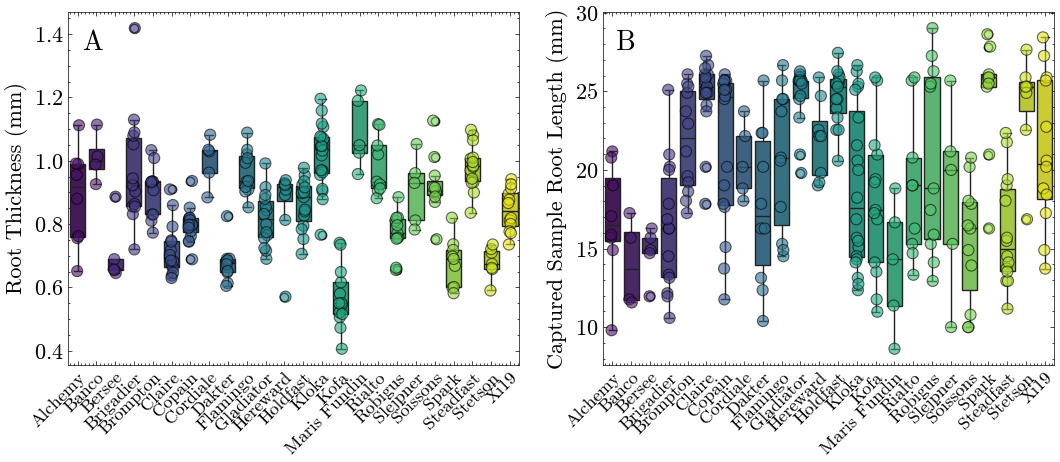

In [28]:
plot_traits(ncols=2,nrows=1,
            figsize=(11,5), 
            traits=['Root Thickness (mm)', 'Root Length (mm)'], 
            labs=['A','B'],
            ylabs=['Root Thickness (mm)',
            'Captured Sample Root Length (mm)'])


Figure 5 - Root Hair Heterogeneity Traits

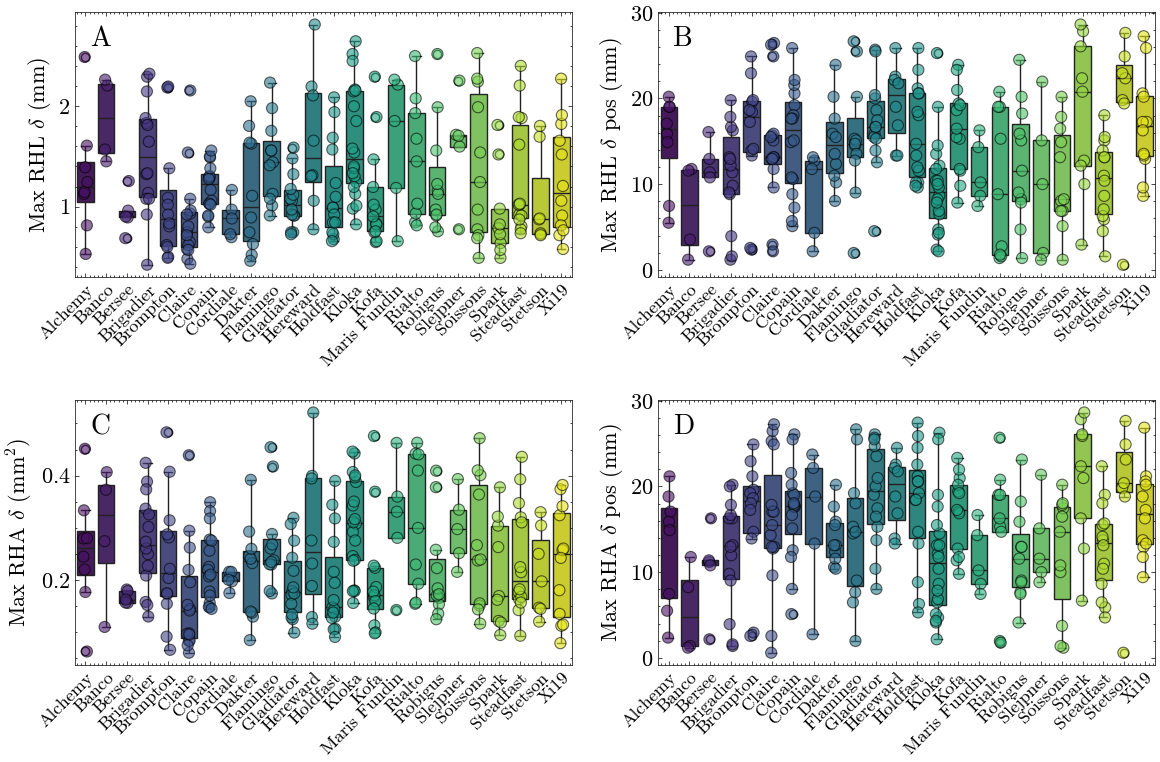

In [29]:
plot_traits(ncols=2,nrows=2,
            figsize=(12,8), 
            traits=['Max RHL Delta (mm)','Max RHL Delta Pos (mm)', 'Max RHA Delta (mm2)','Max RHA Delta Pos (mm)'], 
            labs=['A','B','C','D'],
            ylabs=[ r'Max RHL $\delta$ (mm)',
            r'Max RHL $\delta$ pos (mm)', 
            r'Max RHA $\delta$ (mm$^{2}$)',
            r'Max RHA $\delta$ pos (mm)',])

Figure 6 - Root Hair Elongation Zone Traits

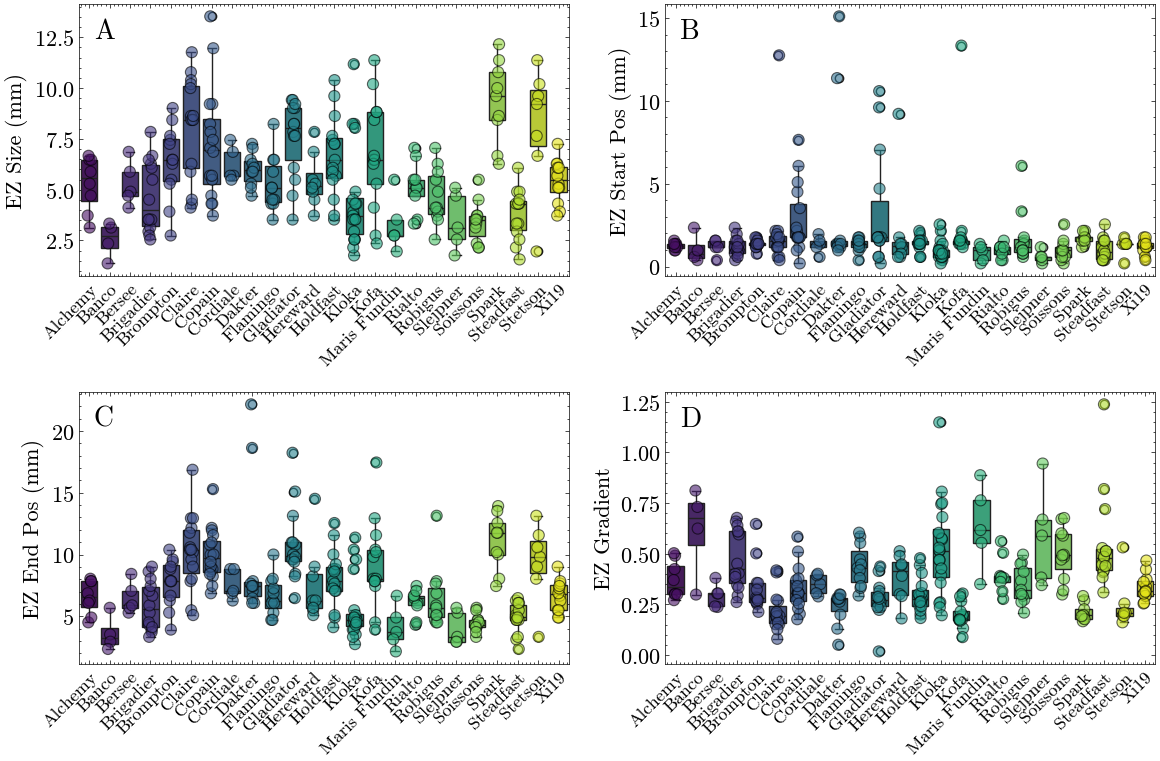

In [31]:
plot_traits(ncols=2, nrows=2,
            figsize=(12,8), 
            traits=['Elongation Zone Distance (mm)','Elongation Zone Start (mm)', 'Elongation Zone Stop (mm)','Elongation Zone Gradient',], 
            labs=['A','B','C','D'],
            ylabs=[r'EZ Size (mm)',
            r'EZ Start Pos (mm)',
            r'EZ End Pos (mm)',
            r'EZ Gradient'])

### Figure 2 - Heatmap Correlation Matrix

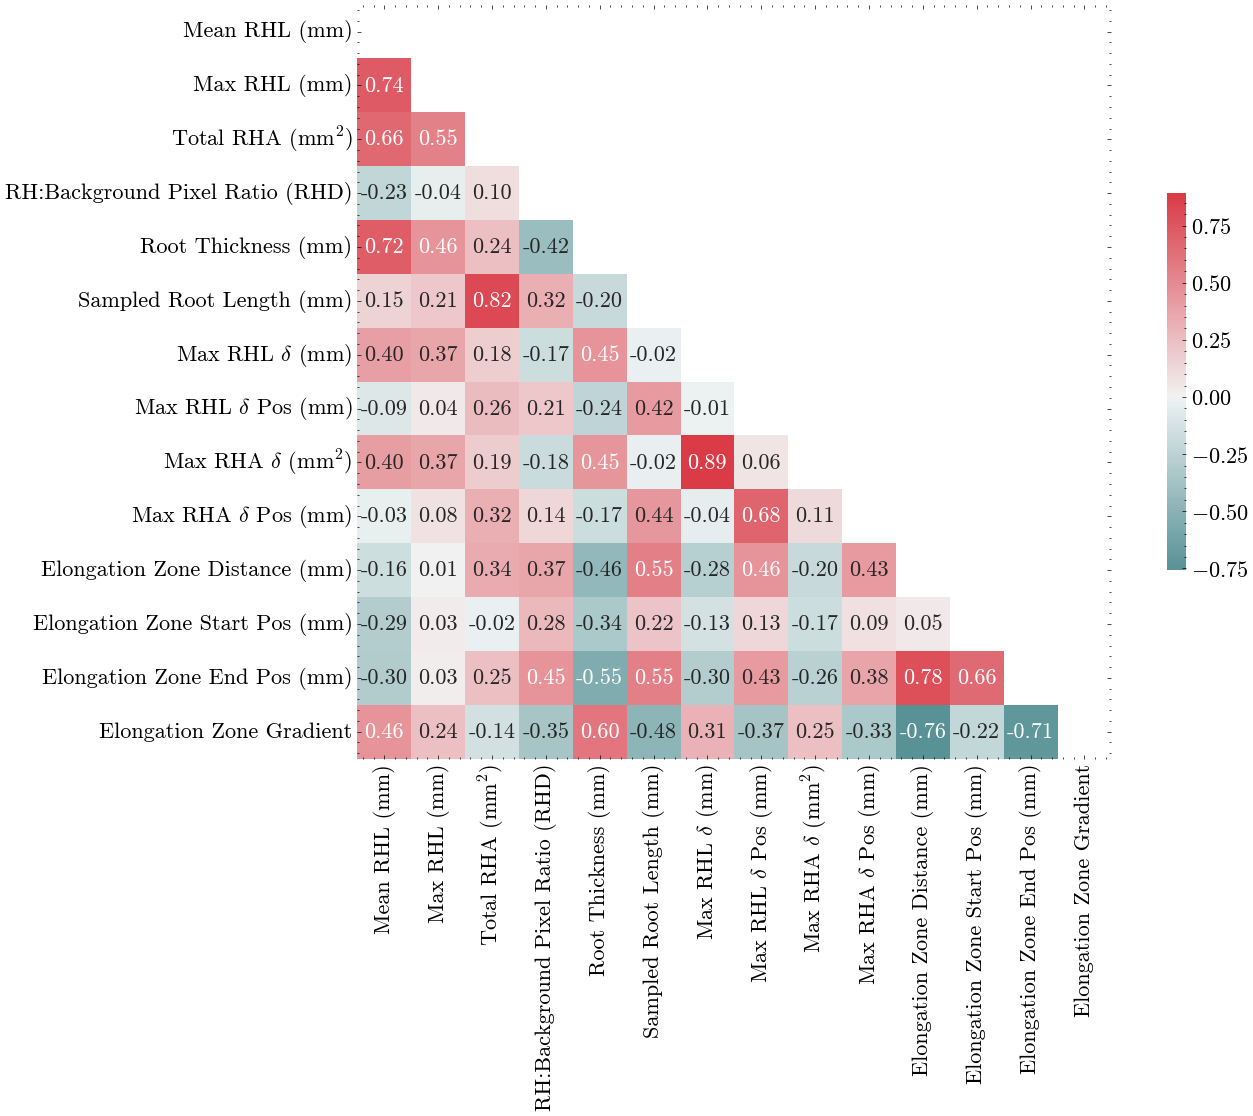

In [69]:
def plot_heatmap():
    plt.rcParams['figure.figsize'] = (16,13)
    plt.gcf().subplots_adjust(bottom=0.3, left=0.2)
    heatmap_df = summary_data.drop(['Min RHL (mm)', 'Name'], axis=1).set_index(['Batch_ID'])
    heatmap_df = heatmap_df.rename(columns={'Total RHA (mm2)': r'Total RHA (mm$^{2}$)',
                            'Root Length (mm)': 'Sampled Root Length (mm)',
                            'Max RHA Delta (mm2)': r'Max RHA $\delta$ (mm$^{2}$)',
                            'Max RHL Delta (mm)': r'Max RHL $\delta$ (mm)',
                            'Max RHA Delta Pos (mm)': r'Max RHA $\delta$ Pos (mm)',
                            'Max RHL Delta Pos (mm)': r'Max RHL $\delta$ Pos (mm)',
                            'Avg RHL (mm)': 'Mean RHL (mm)',
                            'RH:Background Pixel Ratio': 'RH:Background Pixel Ratio (RHD)',
                            'Elongation Zone Start (mm)': 'Elongation Zone Start Pos (mm)',
                            'Elongation Zone Stop (mm)': 'Elongation Zone End Pos (mm)'
                            })

    col_order = ['Mean RHL (mm)', 'Max RHL (mm)', r'Total RHA (mm$^{2}$)', 'RH:Background Pixel Ratio (RHD)',
                'Root Thickness (mm)', 'Sampled Root Length (mm)',
                r'Max RHL $\delta$ (mm)', r'Max RHL $\delta$ Pos (mm)',r'Max RHA $\delta$ (mm$^{2}$)', r'Max RHA $\delta$ Pos (mm)',
                'Elongation Zone Distance (mm)', 'Elongation Zone Start Pos (mm)','Elongation Zone End Pos (mm)','Elongation Zone Gradient'
                ]
    heatmap_df = heatmap_df[col_order]

    corr = heatmap_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(200,10, as_cmap=True), center=0, square=True, cbar_kws={'shrink':.5}, annot=True, fmt='.2f')

plot_heatmap()

### Figure 4 - Wheat Demo

/home/iantsang/python_venv/lib/python3.12/site-packages/matplotlib/text.py:1462: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(x))
/home/iantsang/python_venv/lib/python3.12/site-packages/matplotlib/text.py:894: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))


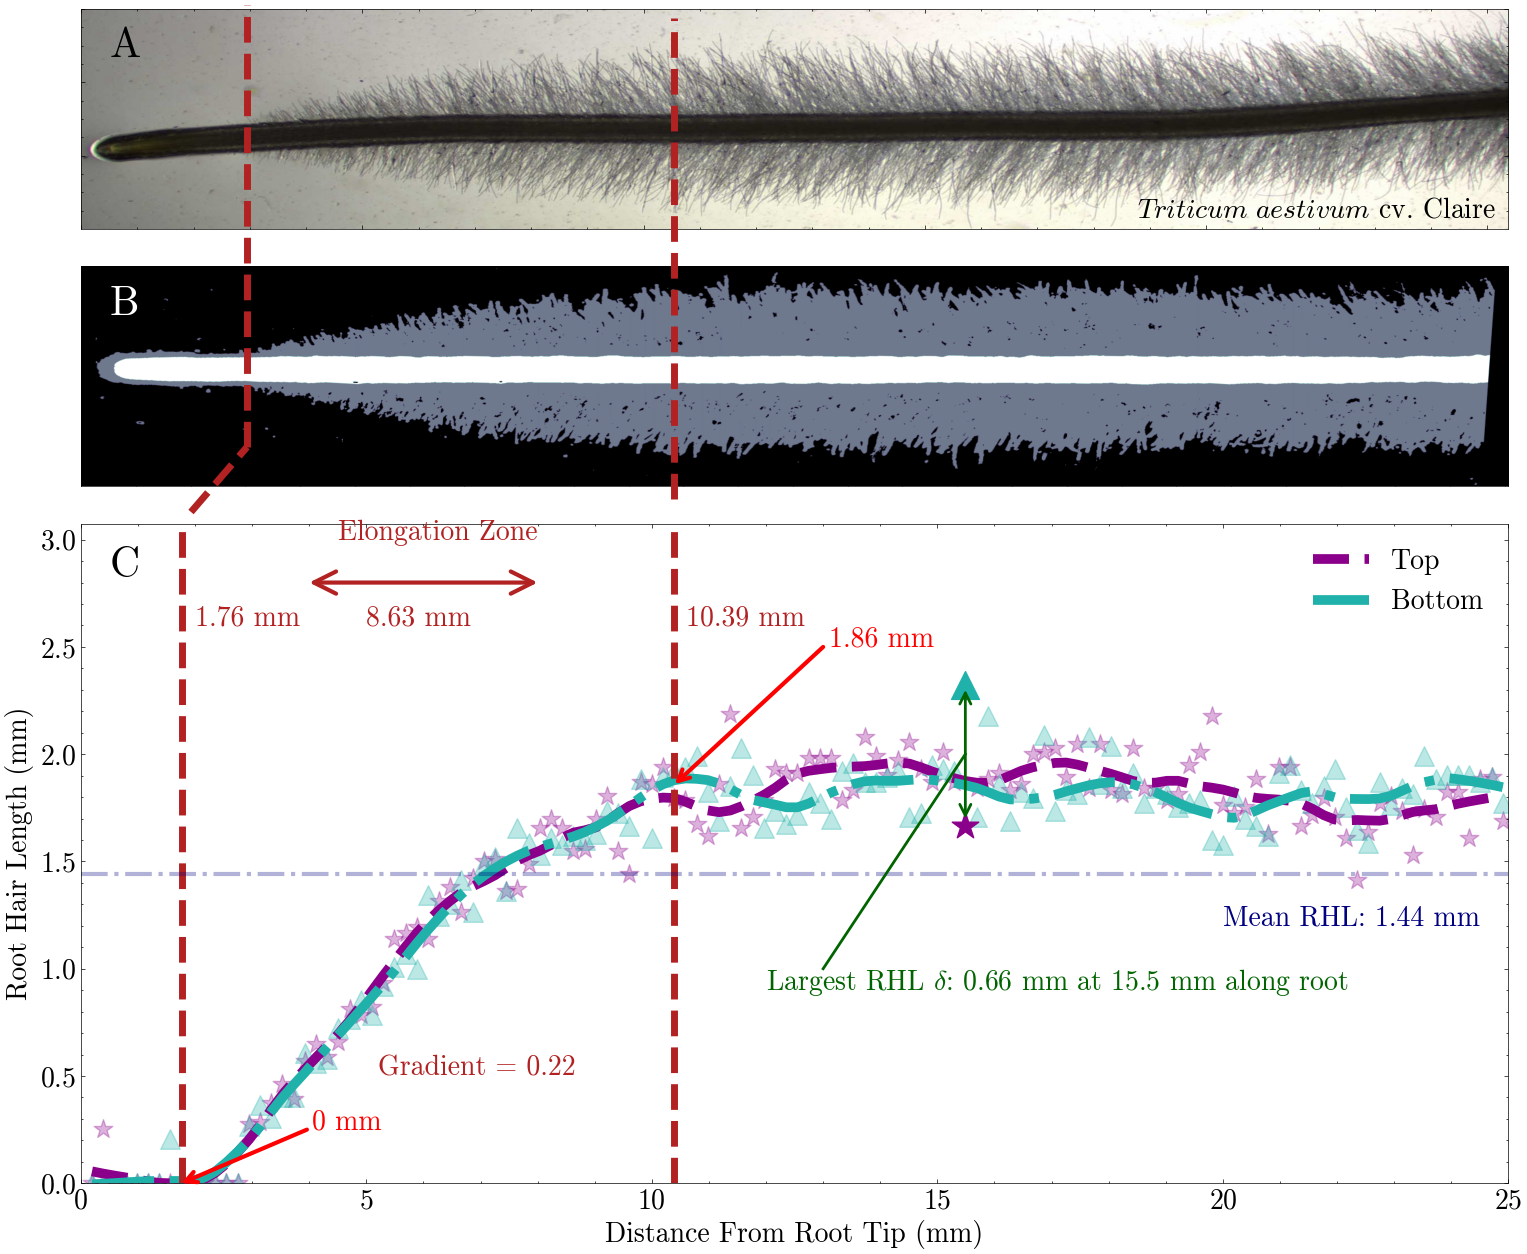

In [70]:
def plot_figure_4():
    # set fontsize
    plt.rcParams['font.size'] = 20
    
    # Images
    claire_raw = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_4/claire_0015.png')
    claire_mask = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_4/claire_0015_mask.png')
    claire_mask = rgb2gray(claire_mask[:,:,:3]) # convert mask to grayscale

    # DataFrames
    claire_raw_df = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_4/Claire_raw.csv')
    claire_summary_df = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_4/Claire_summary.csv')

    # subset for specific image
    claire_raw_df = claire_raw_df[claire_raw_df['Name'] == 'claire_0015']
    claire_summary_df = claire_summary_df[claire_summary_df['Name'] == 'claire_0015']

    # calculate average rhl
    claire_raw_df['Avg RHL'] = claire_raw_df.loc[:, ['RHL 1', 'RHL 2']].mean(axis=1)

    # calculate lowess regression lines
    line1 = lowess(claire_raw_df['RHL 1'], claire_raw_df['Distance From Root Tip (mm)'], frac=0.1)
    line2 = lowess(claire_raw_df['RHL 2'], claire_raw_df['Distance From Root Tip (mm)'], frac=0.1)
    avg = lowess(claire_raw_df['Avg RHL'], claire_raw_df['Distance From Root Tip (mm)'], frac=0.1)
    
    # Plot
    fig, ax = plt.subplots(nrows=3, gridspec_kw={'height_ratios':(1,1,3)}, figsize=(16, 13))

    # Show images
    ax[0].imshow(np.rot90(claire_raw, k=3)[500:1100, 150:], aspect='auto')
    ax[1].imshow(np.rot90(claire_mask, k=3)[600:1200, 150:], cmap='bone', aspect='auto')

    # Plot scatter, lines and annotations
    ax[2].scatter(x=claire_raw_df['Distance From Root Tip (mm)'], 
                y=claire_raw_df['RHL 1'],
                color='darkmagenta',
                marker='*',
                s=200,
                alpha=0.3,
                )
    ax[2].scatter(x=claire_raw_df['Distance From Root Tip (mm)'],
                y=claire_raw_df['RHL 2'],
                color='lightseagreen',
                marker='^',
                alpha=0.3,
                s=200
                )
    ax[2].plot(line1[:,0], line1[:,1], linewidth=7, linestyle='dashed', color='darkmagenta', label='Top') 
    ax[2].plot(line2[:,0], line2[:,1], linewidth=7, linestyle='dashdot', color='lightseagreen', label='Bottom')
    ax[2].plot((claire_summary_df['Elongation Zone Start (mm)'], claire_summary_df['Elongation Zone Start (mm)']), (0, 5), linewidth=5, linestyle='dashed', color='firebrick')
    ax[2].plot((claire_summary_df['Elongation Zone Stop (mm)'], claire_summary_df['Elongation Zone Stop (mm)']), (0, 5),linewidth=5, linestyle='dashed', color='firebrick')
    ax[2].plot((0,25 ), (claire_summary_df['Avg RHL (mm)'], claire_summary_df['Avg RHL (mm)']), linewidth=3, linestyle='dashdot', color='navy', alpha=0.3)
    ax[2].plot((13,15.490),(1,2), color='darkgreen', linewidth=2)
    ax[2].scatter(15.4901,1.667, color='darkmagenta', marker='*',s=400)
    ax[2].scatter(15.4901,2.3235, color='lightseagreen', marker='^', s=400)

    # annotations
    ax[2].annotate(text='', xy=(4,2.8), xytext=(8,2.8), arrowprops=dict(arrowstyle='<->', shrinkA=0, shrinkB=0, linewidth=3, color='firebrick', mutation_scale=40))
    ax[2].annotate(text='Elongation Zone', xy=(4.5,3), color='firebrick')
    ax[2].annotate(text='8.63 mm', xy=(5, 2.6),  color='firebrick')
    ax[2].annotate(text='1.76 mm', xy=(2, 2.6), color='firebrick')
    ax[2].annotate(text='10.39 mm', xy=(10.6, 2.6), color='firebrick')
    ax[2].annotate(text='', xy=(10.4,1.86), xytext=(13,2.5), arrowprops=dict(arrowstyle='->', shrinkA=0, shrinkB=0, linewidth=3, color='red', mutation_scale=20))
    ax[2].annotate(text='1.86 mm', xy=(13.1, 2.5), color='red' )
    ax[2].annotate(text='', xy=(1.76, 0), xytext=(3.96,0.25), arrowprops=dict(arrowstyle='->', shrinkA=0, shrinkB=0, linewidth=3, color='red', mutation_scale=20))
    ax[2].annotate(text='0 mm', xy=(4.05, 0.25), color='red')
    ax[2].annotate(text=r'Gradient = 0.22', xy=(5.2,0.5), color='firebrick')
    ax[2].annotate(text='', xy=(claire_summary_df['Max RHL Segment Delta Pos (mm)'], 1.7), xytext=(claire_summary_df['Max RHL Segment Delta Pos (mm)'],2.3), arrowprops=dict(arrowstyle='<->', shrinkA=0, shrinkB=0, linewidth=2, color='darkgreen', mutation_scale=20))
    ax[2].annotate(text=r'Largest RHL $\delta$: 0.66 mm at 15.5 mm along root', xy=(12, 0.9), color='darkgreen')
    ax[2].annotate(text=r'Mean RHL: 1.44 mm', xy=(20, 1.2), color='navy')

    # Set limits and ticks
    ax[0].set_xticklabels([])
    ax[0].set_yticklabels([])
    ax[1].set_xticklabels([])
    ax[1].set_yticklabels([])
    ax[2].set_ylim(0, max(claire_summary_df['Max RHL (mm)']) * 1.5)
    ax[2].set_xlim(0, 25)
    ax[2].set_xlabel('Distance From Root Tip (mm)')
    ax[2].set_ylabel('Root Hair Length (mm)')
    ax[2].legend(loc='upper right')

    # Add labels
    ax[0].annotate('A', xy=(0.02, 0.78), xycoords='axes fraction', color='black', fontsize=30)
    ax[0].annotate(r'$\it{Triticum \ aestivum}$ cv. Claire', xy=(0.74, 0.05), xycoords='axes fraction', fontsize=20)
    ax[1].annotate('B', xy=(0.02, 0.78), xycoords='axes fraction', color='white', fontsize=30)
    ax[2].annotate('C', xy=(0.02, 0.92), xycoords='axes fraction', color='black', fontsize=30)


    # Add vertical lines between subplots
    line = plt.Line2D((0.17,0.17), (0.64,0.98), transform=fig.transFigure, color='firebrick', linestyle='dashed', linewidth=5)
    fig.add_artist(line)
    line = plt.Line2D((0.437,0.437), (0.6,0.97), transform=fig.transFigure, color='firebrick', linestyle='dashed', linewidth=5)
    fig.add_artist(line)
    line = plt.Line2D((0.135,0.17), (0.59,0.64), transform=fig.transFigure, color='firebrick', linestyle='dashed', linewidth=5)
    fig.add_artist(line)

    plt.tight_layout()
    # plt.savefig('pyroothair_wheat_demo.pdf', format='pdf', dpi=100)
plot_figure_4()

### Figure 7 - Root Tip Variation and Clustering

/tmp/ipykernel_10919/149867920.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df_10cm['RHL_Avg'] = raw_df_10cm[['RHL 1', 'RHL 2']].mean(axis=1)
/tmp/ipykernel_10919/149867920.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_df_10cm.sort_index(inplace=True)
/tmp/ipykernel_10919/149867920.py:113: UserWarning: 
The palette list has fewer values (1) than needed (18) and will cycle, which may produce an uninterpretable plot.
  a = sns.lineplot(data=gray_df,


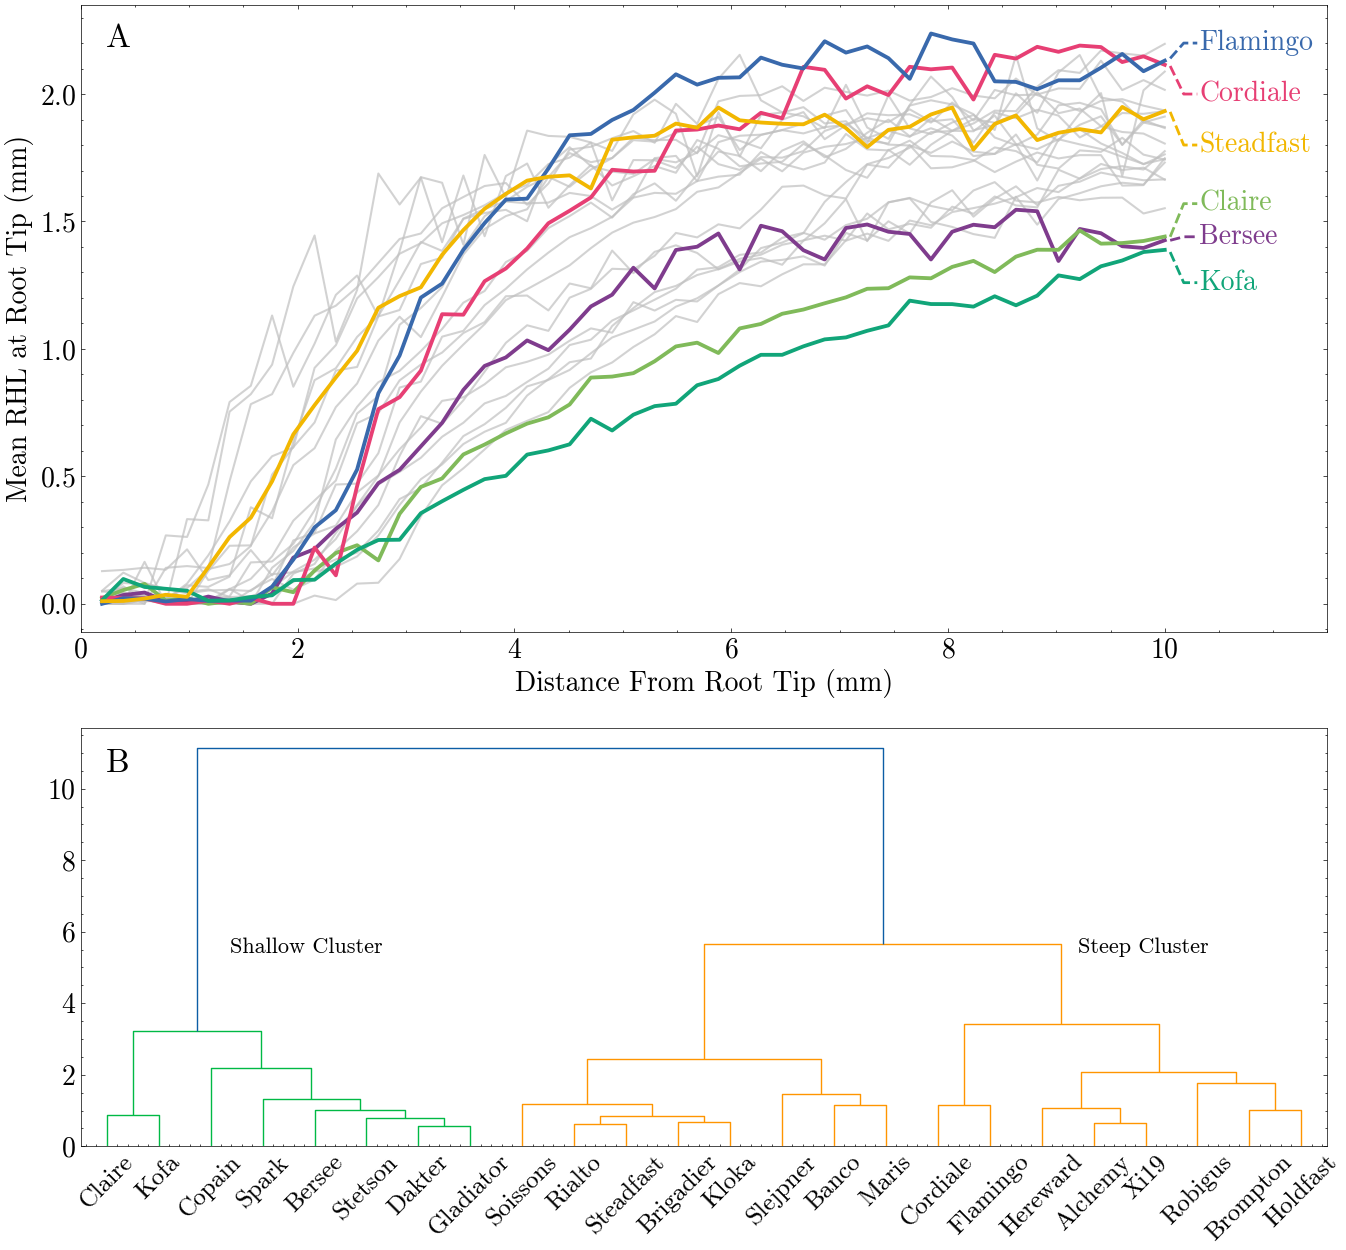

In [72]:
def plot_clustering_and_variation():
    
    # Data
    raw_df = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_7/all_raw.csv')
    raw_df.drop(['Unnamed: 0'], axis=1, inplace=True)
    raw_df[['Genotype', 'Rep', 'NA']] = raw_df['Name'].str.split('_', expand=True)
    raw_df = raw_df.set_index('Genotype').drop(['NA'], axis=1)
    raw_df.drop(['Name'], axis=1, inplace=True)

    # subset for first 10 cm
    raw_df_10cm = raw_df[raw_df['Distance From Root Tip (mm)'] <= 10]
    raw_df_10cm['RHL_Avg'] = raw_df_10cm[['RHL 1', 'RHL 2']].mean(axis=1)
    raw_df_10cm.sort_index(inplace=True)
    
    # determine which cultivars to annotate based on extremes at root tip
    last_point = raw_df_10cm[raw_df_10cm['Distance From Root Tip (mm)'] == 10].reset_index()
    last_point = last_point.drop(['Distance From Root Tip (mm)', 'RHL 1', 'RHL 2', 'RHA 1', 'RHA 2', 'Rep'], axis=1)
    last_point = last_point.groupby(['Genotype']).mean().sort_values(by='RHL_Avg')

    # determine which cultivars to annotate
    # grays -> cultivars to not annotate
    # colors -> cultivars to annotate

    gray_df = raw_df_10cm.reset_index()
    gray_df = gray_df[~gray_df['Genotype'].isin(['kofa', 'bersee', 'claire', 'cordiale', 'flamingo', 'steadfast'])]

    color_df = raw_df_10cm.reset_index()
    color_df = color_df[color_df['Genotype'].isin(['kofa', 'bersee', 'claire', 'cordiale', 'flamingo', 'steadfast'])]

    # set colormap
    custom_colourmap = [
        "#7F3C8D", #bersee violet
        "#80BA5A", #claire olive green
        "#E73F74", #cordiale red
        ""
        "#3969AC", #flamingo blue
        "#11A579", #kofa green
        "#F2B701", #steadfast yellow
    ]

    annotated_genotypes = ['kofa', 'bersee', 'claire', 'cordiale', 'flamingo', 'steadfast']
    
    # Agglomerative clustering to determine clusters

    clustering = raw_df_10cm.reset_index()
    clustering = clustering[['Genotype', 'Distance From Root Tip (mm)', 'RHL_Avg']]
    grouped_df = clustering.groupby(['Genotype', 'Distance From Root Tip (mm)']).mean().reset_index()
    genotype_list = list(clustering['Genotype'].unique())
    grouped_df['Genotype'] = grouped_df['Genotype'].str.title()

    genotype_key = {'alchemy': 0,
    'banco':1,
    'bersee':2,
    'brigadier':3,
    'brompton':4,
    'claire':5,
    'copain':6,
    'cordiale':7,
    'dakter':8,
    'flamingo':9,
    'gladiator':10,
    'hereward':11,
    'holdfast':12,
    'kloka':13,
    'kofa':14,
    'maris':15,
    'rialto':16,
    'robigus':17,
    'slejpner':18,
    'soissons':19,
    'spark':20,
    'steadfast':21,
    'stetson':22,
    'xi19':23}

    grouped_df = grouped_df.pivot(columns='Distance From Root Tip (mm)', index='Genotype', values='RHL_Avg')
    grouped_df = grouped_df.reset_index()
    grouped_df = grouped_df.replace({"Genotype": genotype_key}) # code genotypes with numbers
    features = grouped_df.drop('Genotype', axis=1)
    features = features.to_numpy()

    clustering = AgglomerativeClustering(distance_threshold=0, n_clusters=None).fit(features)
    labels = [i.title() for i in genotype_key]

    # function to plot dendogram from skimage
    def plot_dendrogram(model, ax, **kwargs):
        # Create linkage matrix and then plot the dendrogram

        # create the counts of samples under each node
        counts = np.zeros(model.children_.shape[0])
        n_samples = len(model.labels_)
        for i, merge in enumerate(model.children_):
            current_count = 0
            for child_idx in merge:
                if child_idx < n_samples:
                    current_count += 1  # leaf node
                else:
                    current_count += counts[child_idx - n_samples]
            counts[i] = current_count

        linkage_matrix = np.column_stack(
            [model.children_, model.distances_, counts]
        ).astype(float)

        # Plot the corresponding dendrogram
        dendrogram(linkage_matrix, **kwargs, orientation='top', labels=labels, leaf_font_size=18)
        ax.text(0.02, 0.95, 'B', va='top', transform=ax.transAxes, fontsize=24, weight='bold')
        ax.text(0.12, 0.5, 'Shallow Cluster', va='top', transform=ax.transAxes, fontsize=16)
        ax.text(0.8, 0.5, 'Steep Cluster', va='top', transform=ax.transAxes, fontsize=16)
    
    # function to plot variation
    def plot_variation(ax):
            a = sns.lineplot(data=gray_df,
                    x='Distance From Root Tip (mm)',
                    y='RHL_Avg',
                    hue='Genotype',
                    palette=['silver'],
                    markers=True,
                    errorbar=None,
                    linewidth=1.5,
                    legend=False,
                    alpha=0.7,
                    ax=ax
                    )
            a.set_ylabel('Mean RHL at Root Tip (mm)')

            sns.lineplot(data=color_df,
                            x='Distance From Root Tip (mm)',
                            y='RHL_Avg',
                            hue='Genotype',
                            palette=custom_colourmap,
                            markers=True,
                            errorbar=None,
                            linewidth=2.75,
                            legend=False,
                            ax=ax
                    )
                            
            ax.text(10.32, 1.26, 'Kofa', color=custom_colourmap[4], fontsize=20,  va='center')
            ax.text(10.32, 1.44, 'Bersee', color=custom_colourmap[0], fontsize=20,  va='center')
            ax.text(10.32, 1.57, 'Claire', color=custom_colourmap[1], fontsize=20,  va='center')
            ax.text(10.32, 1.8, 'Steadfast', color=custom_colourmap[5], fontsize=20, va='center')
            ax.text(10.32, 2, 'Cordiale', color=custom_colourmap[2], fontsize=20,  va='center')
            ax.text(10.32, 2.2, 'Flamingo', color=custom_colourmap[3], fontsize=20,  va='center')

            start = 10.05
            end = 10.35
            pad = 0.05

            ax.plot([start, (start + end - pad) / 2, end - pad],
                    [1.38, 1.26,1.26],
                    color=custom_colourmap[4],
                    ls='dashed',
                    linewidth=2)
            ax.plot([start, (start + end - pad) / 2, end - pad],
                    [1.426, 1.44,1.44],
                    color=custom_colourmap[0],
                    ls='dashed',
                    linewidth=2)
            ax.plot([start, (start + end - pad) / 2, end - pad],
                    [1.44, 1.57,1.57],
                    color=custom_colourmap[1],
                    ls='dashed',
                    linewidth=2)
            ax.plot([start, (start + end - pad) / 2, end - pad],
                    [2.11, 2,2],
                    color=custom_colourmap[2],
                    ls='dashed',
                    linewidth=2)
            ax.plot([start, (start + end - pad) / 2, end - pad],
                    [2.14, 2.2,2.2],
                    color=custom_colourmap[3],
                    ls='dashed',
                    linewidth=2)
            ax.plot([start, (start + end - pad) / 2, end - pad],
                    [1.93, 1.8,1.8],
                    color=custom_colourmap[5],
                    ls='dashed',
                    linewidth=2)

            ax.set_xlim(0, 11.5)
            ax.text(0.02, 0.97, 'A', va='top', transform=ax.transAxes, fontsize=24, weight='bold')

    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14,13), gridspec_kw={'height_ratios':[1.5,1]})
    plot_variation(ax=ax[0])
    plot_dendrogram(clustering, ax=ax[1])
    plt.tight_layout()
        
plot_clustering_and_variation()

### Figure 8 - Species Demo

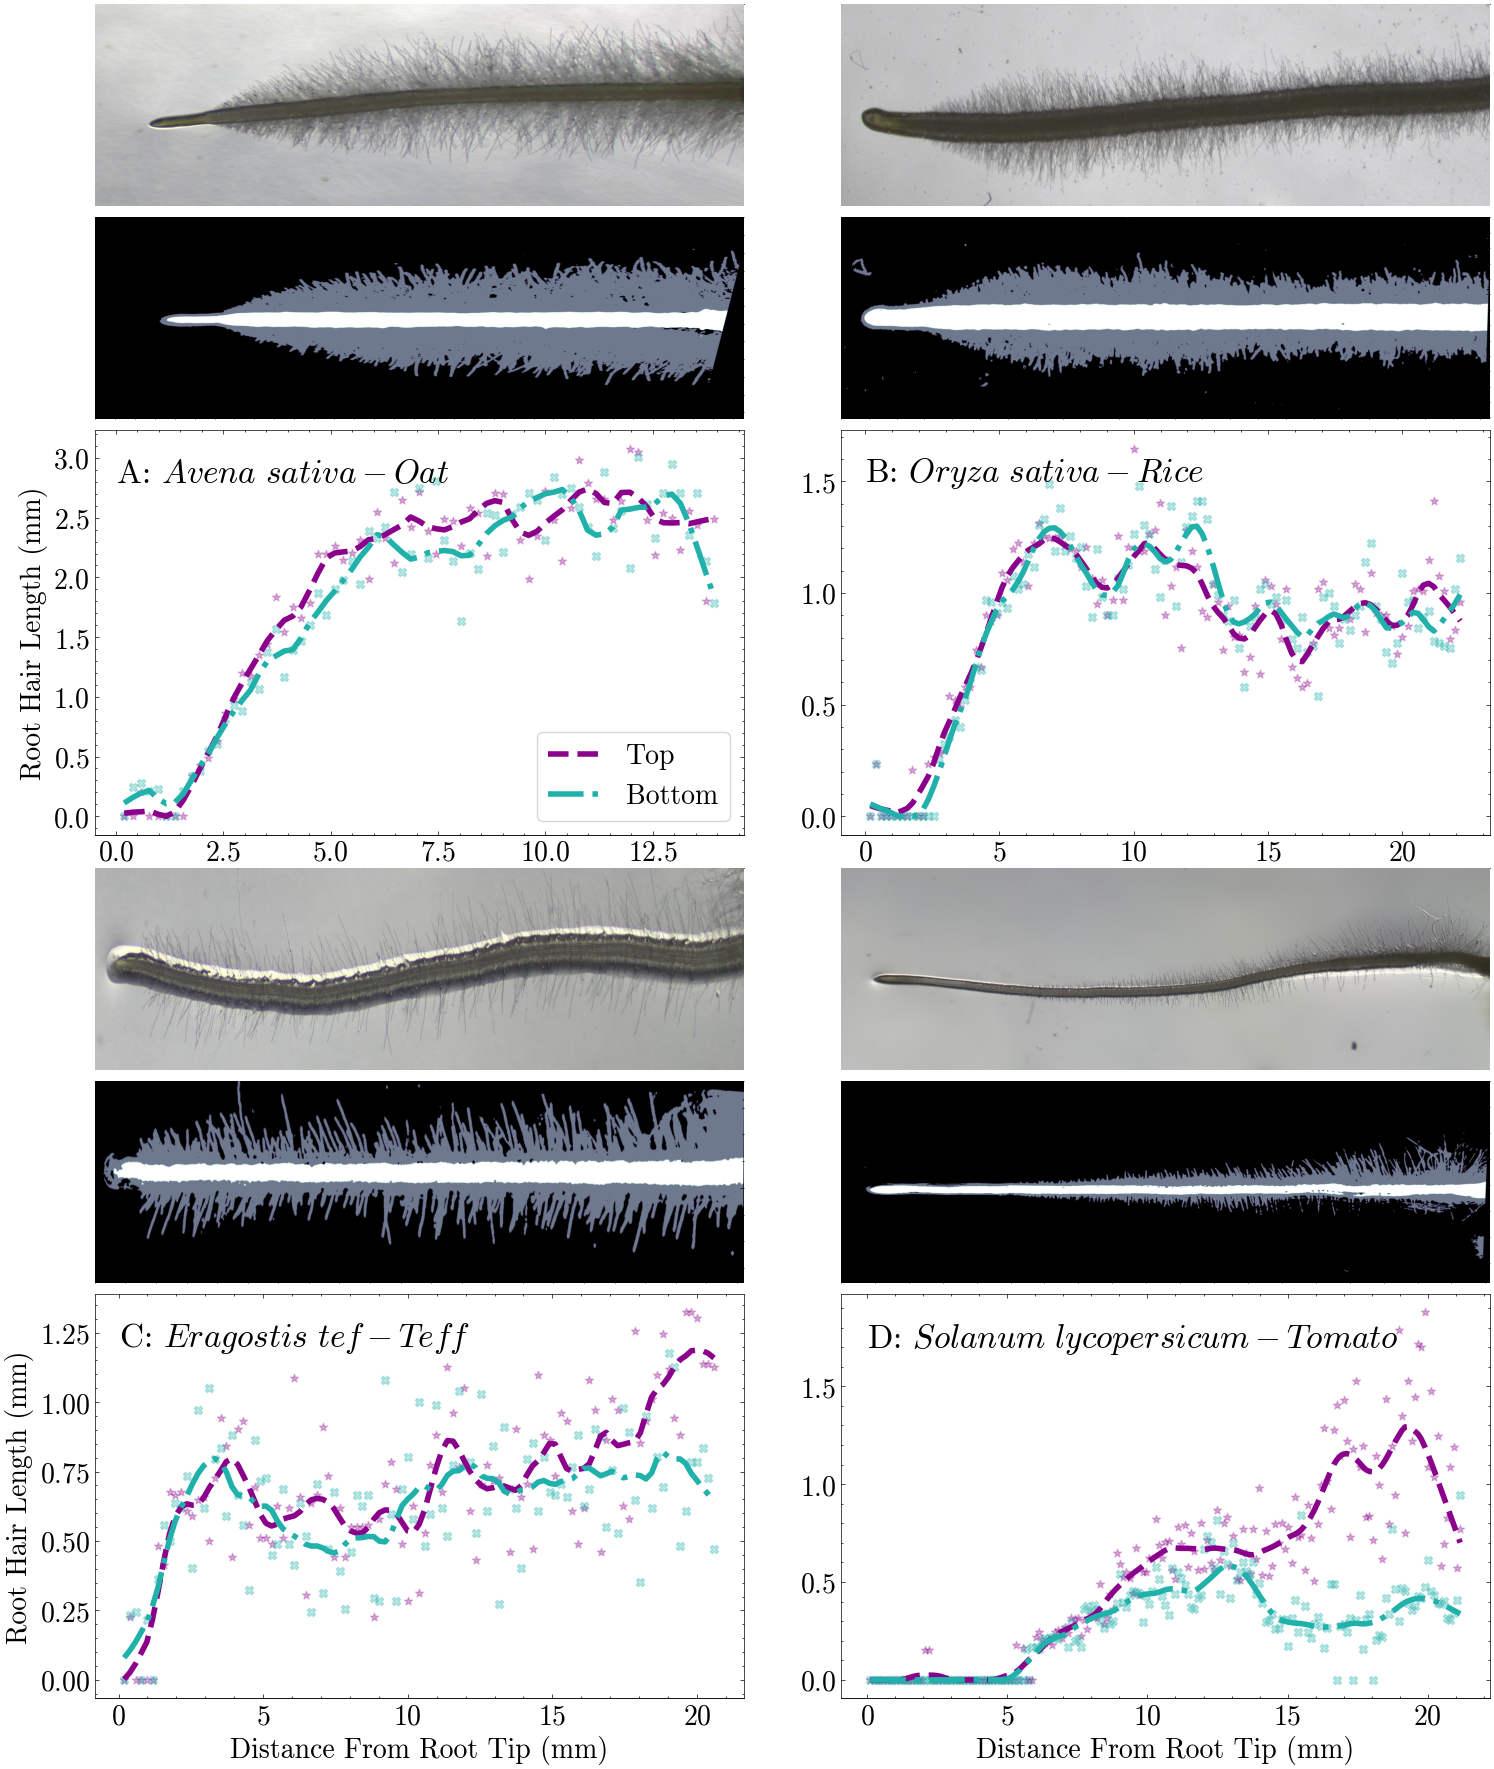

In [74]:
def plot_species_demo():
    # Load in all images
    rice_data = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_8/rice_raw.csv')
    rice_mask = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/nipponbare_1_mask.png')
    rice_raw = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/nipponbare_stitch_0001.1.png')


    oat_data = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_8/oat_raw.csv')
    oat_mask = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/saladin_0003_mask.png')
    oat_raw = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/saladin_0003.png')

    teff_raw = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/tef_0001.png')
    teff_mask = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/tef_0001_mask.png')
    teff_data = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_8/teff_raw.csv')

    tomato_raw = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/tomato_stitch.png')
    tomato_mask = iio.imread('/home/iantsang/pyRootHair/paper_data/Figure_8/tomato_stitch_mask.png')
    tomato_data = pd.read_csv('/home/iantsang/pyRootHair/paper_data/Figure_8/tomato_raw.csv')
    
    # calculate and plot rhl regressions
    def plot_rhls(df, ax):
        smooth_1_rhl = lowess(df['RHL 1'], df['Distance From Root Tip (mm)'], frac=0.1)
        smooth_2_rhl = lowess(df['RHL 2'], df['Distance From Root Tip (mm)'], frac=0.1)
        ax.scatter(x=df['Distance From Root Tip (mm)'], y=df['RHL 1'], color='darkmagenta', marker='*', alpha=0.3)
        ax.scatter(x=df['Distance From Root Tip (mm)'], y=df['RHL 2'], color='lightseagreen', marker='X', alpha=0.3)
        ax.plot(smooth_1_rhl[:, 0], smooth_1_rhl[:, 1], color='darkmagenta', linewidth=4, linestyle='dashed', label='Top')
        ax.plot(smooth_2_rhl[:, 0], smooth_2_rhl[:, 1], color='lightseagreen', linewidth=4, linestyle='dashdot', label='Bottom')

    # gridspec sub fig function
    def subfigs(fig, gs, raw, mask, df, aspect, label, xlab, lab_x, lab_y, ylab, legend):
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1])
        ax3 = fig.add_subplot(gs[2])
        
        fig.subplots_adjust(hspace=0.04)
        
        ax1.imshow(np.rot90(raw, k=3), aspect=aspect)
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.spines['top'].set_visible(False)
        ax1.spines['bottom'].set_visible(False)
        ax1.spines['left'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax2.imshow(np.rot90(mask, k=3), cmap='bone', aspect=aspect)
        ax2.set_xticklabels([])
        ax2.set_yticklabels([])
        ax2.spines['top'].set_visible(False)
        ax2.spines['bottom'].set_visible(False)
        ax2.spines['left'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        plot_rhls(df, ax=ax3)
        if xlab:
            ax3.set_xlabel('Distance From Root Tip (mm)')
        if ylab:
            ax3.set_ylabel('Root Hair Length (mm)')
        ax3.text(lab_x, lab_y, label, fontsize=24)
        if legend:
            ax3.legend(loc='lower right', fancybox=True, frameon=True)

    # clean up axes for each gridspec plot
    def clean_ax(ax):
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines.left.set_visible(False)
        ax.spines.right.set_visible(False)

    
    fig = plt.figure(figsize=(18,22))
    gs = GridSpec(2,2,height_ratios=[1,1])
    fig.subplots_adjust(wspace=0.15, hspace=100)

    ax1 = fig.add_subplot(gs[0])
    clean_ax(ax1)
    subfigs(fig, gs[0].subgridspec(3,1, height_ratios=[0.4,0.4,0.8]), oat_raw, rgb2gray(oat_mask.copy()[:,:,:3]), oat_data, 'auto',  r'A: $\it{Avena\ sativa} - Oat$', False, 0,2.8, True, True)

    ax2 = fig.add_subplot(gs[1])
    clean_ax(ax2)
    subfigs(fig, gs[1].subgridspec(3,1, height_ratios=[0.4,0.4,0.8]), rice_raw, rgb2gray(rice_mask.copy()[:,:,:3]), rice_data, 'auto',  r'B: $\it{Oryza\ sativa} - Rice$', False, 0,1.5, False, False)

    ax3 = fig.add_subplot(gs[2])
    clean_ax(ax3)
    subfigs(fig, gs[2].subgridspec(3,1, height_ratios=[0.4,0.4,0.8]), teff_raw, rgb2gray(teff_mask.copy()[:,:,:3]), teff_data, 'auto', r'C: $\it{Eragostis\ tef} - Teff$', True, 0, 1.2, True, False)


    ax4 = fig.add_subplot(gs[3])
    clean_ax(ax4)
    subfigs(fig, gs[3].subgridspec(3,1, height_ratios=[0.4,0.4,0.8]), tomato_raw, rgb2gray(tomato_mask.copy()[:,:,:3]), tomato_data, 'auto',r'D: $\it{Solanum\ lycopersicum} - Tomato$', True, 0, 1.7, False,False)

plot_species_demo()

### Figure 9 - Correlation Plots

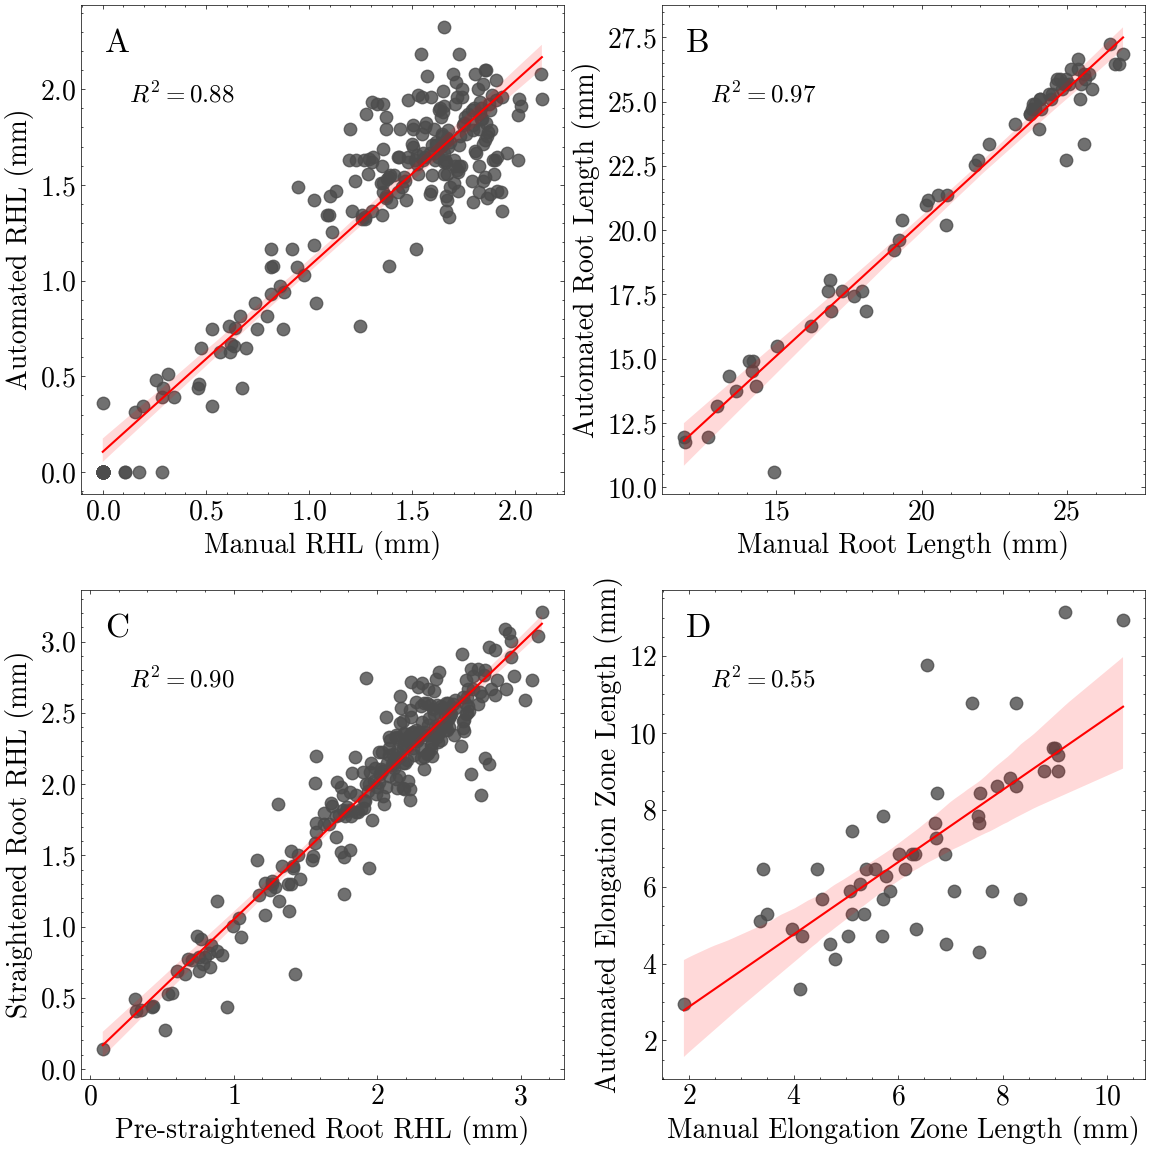

In [75]:
def plot_correlations():
    # Load Data
    data = pd.read_excel('/home/iantsang/pyRootHair/paper_data/Figure_9/manual_measurements.xlsx')
    root = pd.read_excel('/home/iantsang/pyRootHair/paper_data/Figure_9/manual_measurements.xlsx', sheet_name='Root Length')
    elongation_data = pd.read_excel('/home/iantsang/pyRootHair/paper_data/Figure_9/manual_measurements.xlsx', sheet_name='Elongation')
    straightening_data = pd.read_excel('/home/iantsang/pyRootHair/paper_data/Figure_9/qc_root_straightening.xlsx')

    def calc_corr(df, x, y, ax, xlab, ylab, label):
        z = sns.regplot(df,
                x=x,
                y=y,
                ci=99,
                color='.3',
                marker='o',
                line_kws=dict(color='r'),
                scatter_kws={'s':80},
                ax=ax
                )
        slope, intercept, r, p, stderr = linregress(df[y], df[x])
        rsq = r ** 2
        
        z.set_xlabel(xlab)
        z.set_ylabel(ylab)
        ax.text(0.05, 0.95, label, va='top', transform=ax.transAxes, fontsize=24, weight='bold')

        z.text(0.1, 0.8, f'$R^{2} = {rsq:.2f}$', transform=z.transAxes, fontsize=18)
    
    _, ax = plt.subplots(2,2, figsize=(12,12))
    calc_corr(data, 'rhl_manual', 'rhl_auto', ax[0,0], 'Manual RHL (mm)', 'Automated RHL (mm)', 'A')
    calc_corr(root, 'manual_root_length', 'auto_root_length', ax[0,1], 'Manual Root Length (mm)', 'Automated Root Length (mm)', 'B')
    calc_corr(straightening_data, 'RHL_raw','RHL_Straighten', ax[1,0], 'Pre-straightened Root RHL (mm)', 'Straightened Root RHL (mm)', 'C')
    calc_corr(elongation_data, 'manual_elongation', 'auto_elongation', ax[1,1], 'Manual Elongation Zone Length (mm)', 'Automated Elongation Zone Length (mm)', 'D')
    # plot_corr(other_species, 'manual', 'auto', ax[1,1], 'Manual RHL Length (mm)', 'Automated  RHL (mm)', 'E')

    plt.tight_layout()

plot_correlations()


    

### Supplementary Figure 2 - RHL Validation in Other Species

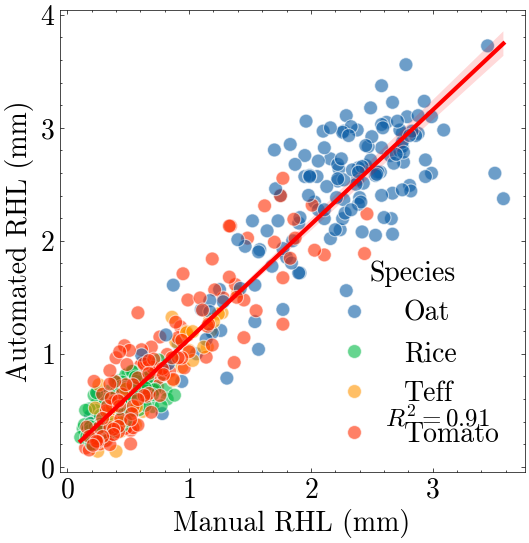

In [76]:
def plot_rhl_validation_other_species():
    _, ax = plt.subplots(figsize=(6,6))
    other_species = pd.read_excel('/home/iantsang/pyRootHair/paper_data/Figure_9/manual_measurements.xlsx', sheet_name='RHL_Corr_OtherSp')    

    sns.scatterplot(other_species, x='manual', y='auto',hue='Species', markers=True, s=100, alpha=0.6)
    sns.regplot(other_species,  x='manual', y='auto',scatter=False, color='red', line_kws={'linewidth': 3})
    slope, intercept, r, p, stderr = linregress(other_species['manual'], other_species['auto'])
    rsq = r ** 2
    ax.text(0.7, 0.1, f'$R^{2} = {rsq:.2f}$', transform=ax.transAxes, fontsize=18)
    ax.set_ylabel('Automated RHL (mm)')
    ax.set_xlabel('Manual RHL (mm)')

plot_rhl_validation_other_species()

### Supplementary Figure 3 - Automated Root Hair Elongation Zone Calculation

The arrays were pre-computed on a single example image for the purposes of S.Figure 3,8,9

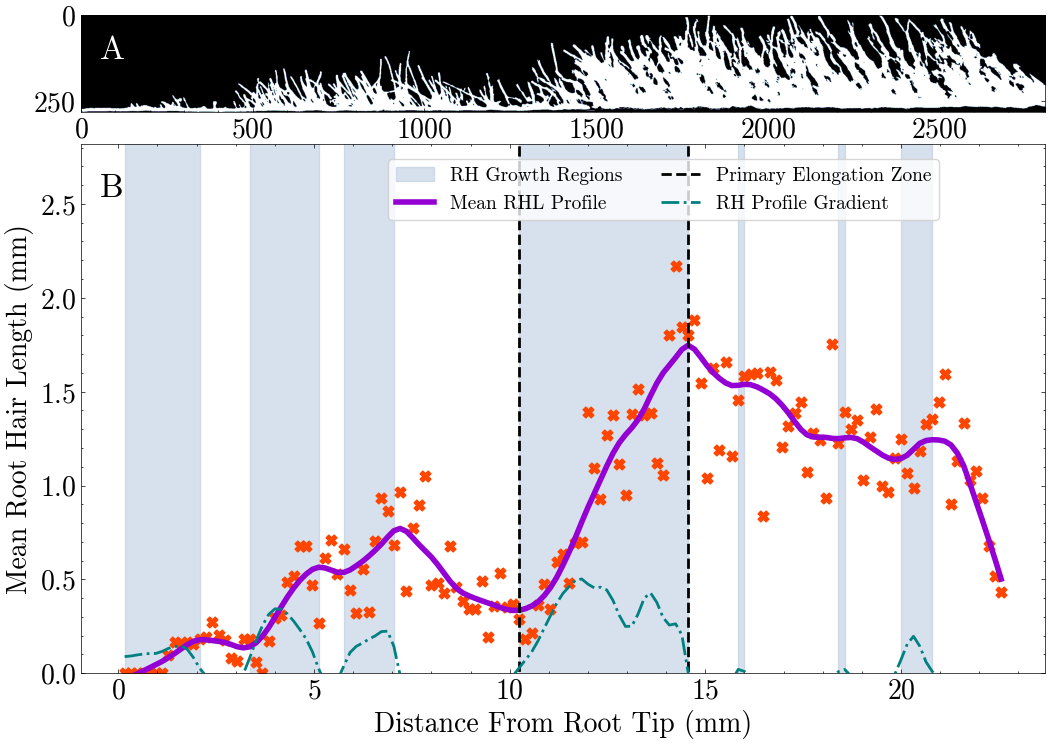

In [77]:
def plot_elongation_zone_example():
    # load pre-computed arrays for the specific image example
    segment_mask = np.load('/home/iantsang/pyRootHair/paper_data/S_Figure_3/segment_mask_array.npy') # array of root hair mask
    smooth_avg_rhl = np.load('/home/iantsang/pyRootHair/paper_data/S_Figure_3/smooth_avg_rhl.npy') # array of smoothed root hair profile (red line in figure)
    gradient = np.load('/home/iantsang/pyRootHair/paper_data/S_Figure_3/gradient.npy') # gradient of smooth root hair line (dashed green line)
    pos_regions = np.load('/home/iantsang/pyRootHair/paper_data/S_Figure_3/pos_regions.npy') # boolean array of regions where root hair gradient > 0
    bin_list = np.load('/home/iantsang/pyRootHair/paper_data/S_Figure_3/bin_list.npy') # x axis (distance from root tip)
    avg_rhl_list = np.load('/home/iantsang/pyRootHair/paper_data/S_Figure_3/avg_rhl_list.npy') # y axis (rhl per bin)
    
    min_x, max_x = 10.24, 14.56
    
    _, ax = plt.subplots(nrows=2, figsize=(11,10))

    ax[0].imshow(np.rot90(segment_mask, k=3), cmap='bone')
    ax[0].annotate('A', xy=(0.02,0.55), xycoords='axes fraction', color='white', fontsize=24)
    ax[1].fill_between(smooth_avg_rhl[:, 0], min(gradient) * 1.1, max(avg_rhl_list) * 2, where=pos_regions, color='lightsteelblue', alpha=0.5, label='RH Growth Regions')        
    ax[1].scatter(x=bin_list, y=avg_rhl_list, color='orangered', s=60, marker='X')
    ax[1].plot(smooth_avg_rhl[:, 0], smooth_avg_rhl[:, 1], color='darkviolet', linewidth=4, label='Mean RHL Profile')
    ax[1].plot((min_x, min_x), (-1, 10), color='black', linewidth=2, linestyle='dashed', label='Primary Elongation Zone')
    ax[1].plot((max_x, max_x),(-1, 10), color='black', linewidth=2, linestyle='dashed')
    ax[1].plot(smooth_avg_rhl[:, 0], gradient, color='teal', linewidth=2, linestyle='dashdot', label='RH Profile Gradient')
    ax[1].set_ylim(0, max(avg_rhl_list) * 1.3)
    ax[1].set_xlabel('Distance From Root Tip (mm)')
    ax[1].set_ylabel('Mean Root Hair Length (mm)')
    ax[1].legend(loc='upper right', fancybox=True, frameon=True, bbox_to_anchor=(.9, 0.99), ncol=2, fontsize=14)
    ax[1].annotate('B', xy=(0.02,0.9), xycoords='axes fraction', color='black', fontsize=24)
    plt.tight_layout(h_pad=-3)

plot_elongation_zone_example()

### Supplementary Figure 5 - GPU vs RFC Pipeline

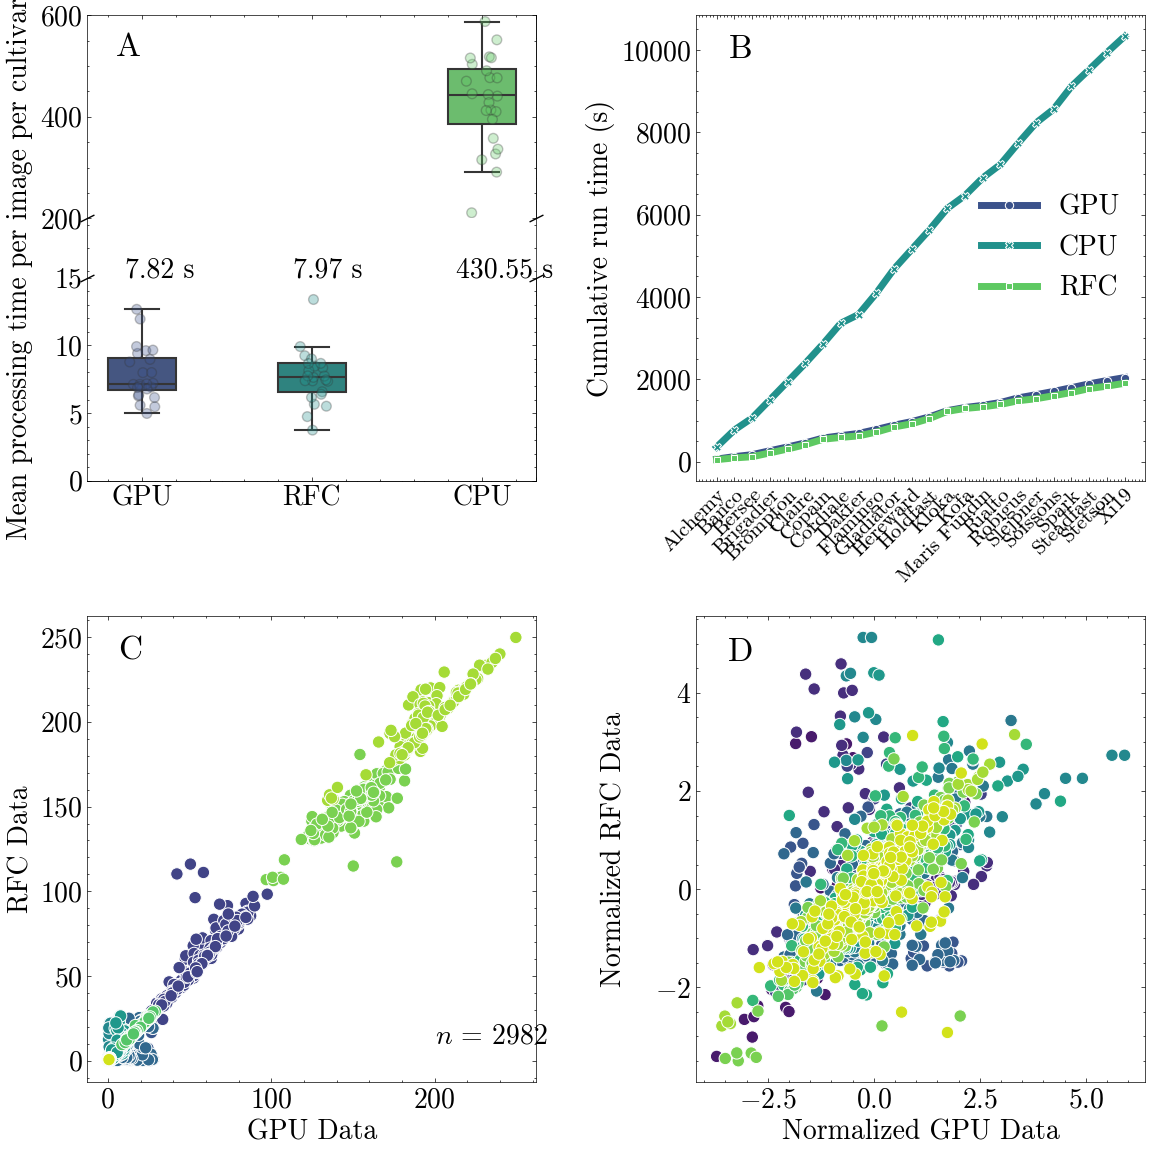

In [79]:
def plot_gpu_vs_rfc():
    # Load data
    # Pipleine Run Time Data
    time = pd.read_excel('/home/iantsang/pyRootHair/paper_data/S_Figure_5/GPU_VS_RFC_TIME.xlsx')
    time.rename(columns={'CUMULATIVE_TIME_GPU': 'GPU',
                                'CUMULATIVE_TIME_RFC': 'RFC',
                                'CUMULATIVE_TIME_NOGPU': 'CPU'}, inplace=True)
    time_melted = pd.melt(time, id_vars=['Genotype'], value_vars=['GPU_TIME_PER_IMAGE', 'RFC_TIME_PER_IMAGE', 'NOGPU_TIME_PER_IMAGE'])

    gpu_only = time_melted[time_melted['variable'] == 'GPU_TIME_PER_IMAGE']                             
    rfc_only = time_melted[time_melted['variable'] == 'RFC_TIME_PER_IMAGE']
    nogpu_only = time_melted[time_melted['variable'] == 'NOGPU_TIME_PER_IMAGE']

    gpu_mean = gpu_only['value'].mean()
    rfc_mean = rfc_only['value'].mean()
    nogpu_mean = nogpu_only['value'].mean()
    
    # cumulative time
    cum_time = pd.melt(time, id_vars=['Genotype'], value_vars=['GPU','CPU','RFC'])
    
    # Gpu and RFC summary data
    gpu = pd.read_csv('/home/iantsang/pyRootHair/paper_data/S_Figure_5/all_summary.csv')
    rfc = pd.read_csv('/home/iantsang/pyRootHair/paper_data/S_Figure_5/all_summary_rfc.csv')

    gpu.rename(columns={'Total RHA (mm2)': 'Total RHA (mm$^{2}$)'}, inplace=True)
    rfc.rename(columns={'Total RHA (mm2)': 'Total RHA (mm$^{2}$)'}, inplace=True)

    gpu.drop(['Unnamed: 0', 'Min RHL (mm)', 'Max RHA Delta (mm2)', 'Max RHL Delta (mm)'], axis=1, inplace=True)
    rfc.drop(['Unnamed: 0', 'Min RHL (mm)', 'Max RHA Delta (mm2)', 'Max RHL Delta (mm)'], axis=1, inplace=True)

    non_n_columns_rfc = rfc[['Name', 'Batch_ID']] # subset non numeric columns pre normalization
    non_n_columns_gpu = gpu[['Name', 'Batch_ID']]

    rfc_norm = rfc.drop(['Name', 'Batch_ID'], axis=1)
    gpu_norm = gpu.drop(['Name', 'Batch_ID'], axis=1)

    rfc_melt = pd.melt(rfc, id_vars=['Name', 'Batch_ID'])
    gpu_melt = pd.melt(gpu, id_vars=['Name', 'Batch_ID'])

    # Normalize data
    normalized_rfc = (rfc_norm-rfc_norm.mean())/rfc_norm.std()
    normalized_gpu = (gpu_norm-gpu_norm.mean())/gpu_norm.std()

    rfc_norm = pd.concat([non_n_columns_rfc, normalized_rfc], axis=1) # add non numeric columns back post normalization
    gpu_norm = pd.concat([non_n_columns_gpu, normalized_gpu], axis=1)

    rfc_melt_norm = pd.melt(rfc_norm, id_vars=['Name', 'Batch_ID'])
    gpu_melt_norm = pd.melt(gpu_norm, id_vars=['Name', 'Batch_ID'])

    combined = gpu_melt.merge(rfc_melt, how='inner', on=['Name', 'variable'])
    combined = combined.drop(['Batch_ID_x'], axis=1)

    combined_norm = gpu_melt_norm.merge(rfc_melt_norm, how='inner', on=['Name', 'variable'])
    combined_norm = combined_norm.drop(['Batch_ID_x'], axis=1)
    
    # function to plot subplot A (for axis break)
    def time_box(fig, gs):

        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1], sharex=ax1)

        fig.subplots_adjust(hspace=0.1)
        sns.boxplot(time_melted, y='value', x='variable', hue='variable', palette='viridis', width=0.4, linewidth=1.5, showfliers=False, ax=ax1)
        sns.stripplot(time_melted, x='variable', y='value', hue='variable', palette='viridis', alpha=0.3, linewidth=1, s=7, ax=ax1)

        sns.boxplot(time_melted, y='value', x='variable', hue='variable', palette='viridis', width=0.4, linewidth=1.5, showfliers=False, ax=ax2)
        sns.stripplot(time_melted, x='variable', y='value', hue='variable', palette='viridis', alpha=0.3, linewidth=1, s=7, ax=ax2)

        ax1.set_ylim(200,600)
        ax2.set_ylim(0, 15)

        d=.5
        kwargs = dict(marker=[(-1, -d), (1, d)], markersize=10,
                    linestyle="none", color='k', mec='k', mew=1, clip_on=False)
        ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
        ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

        ax2.set_xlabel('Pipeline')
        ax2.set_xticks([0,1,2], ['GPU', 'RFC', 'CPU'])
        ax1.text(-0.15,520,'A', fontsize=24)
        ax2.text(-0.1, 15, f'{gpu_mean:.2f} s')
        ax2.text(0.89,15, f'{rfc_mean:.2f} s')
        ax2.text(1.85, 15, f'{nogpu_mean:.2f} s')

        ax1.spines.bottom.set_visible(False)
        ax2.spines.top.set_visible(False)
        ax1.xaxis.tick_top()
        ax2.xaxis.tick_bottom()

        ax1.tick_params(labeltop=False)  # don't put tick labels at the top
        ax1.set_xlabel('')
        ax1.set_ylabel('')
        ax2.set_xlabel('')
        ax2.set_ylabel('')
    
    # Create figure
    fig = plt.figure(figsize=(12,12))
    fig.subplots_adjust(hspace=0.3, wspace=0.15)
    gs = GridSpec(2,2, height_ratios=[1,1])

    ax1 = fig.add_subplot(gs[0])
    ax1.set_xticklabels([])
    ax1.set_yticklabels([])
    time_box(fig, gs[0].subgridspec(2,1, height_ratios=[1,1]))
    ax1.set_ylabel('Mean processing time per image per cultivar (s)', labelpad=35)

    ax2 = fig.add_subplot(gs[1])
    sns.lineplot(cum_time, x='Genotype', y='value', hue='variable', ax=ax2, palette='viridis', linewidth=5, style='variable', markers=True, legend='brief', dashes=False)
    labels = list(time_melted['Genotype'].unique())
    ax2.set_xticks(labels)
    ax2.set_xticklabels(labels, rotation=45, ha='right', rotation_mode='anchor', fontsize=15)
    ax2.legend(title='', loc='right')
    ax2.set_ylabel('Cumulative run time (s)')
    ax2.set_xlabel('')
    ax2.text(0.7, 9800, 'B', fontsize=24)

    ax3 = fig.add_subplot(gs[2])
    sns.scatterplot(combined, x='value_x', y='value_y', hue='variable', palette='viridis', legend=False, ax=ax3, s=80)
    ax3.set_xlabel('GPU Data')
    ax3.set_ylabel('RFC Data')
    ax3.text(6,237,'C', fontsize=24)
    ax3.text(200, 10, fr'$n$ = {len(combined)}')

    ax4 = fig.add_subplot(gs[3])
    sns.scatterplot(combined_norm, x='value_x', y='value_y', hue='variable', palette='viridis', legend=False, ax=ax4, s=80)
    ax4.set_xlabel('Normalized GPU Data')
    ax4.set_ylabel('Normalized RFC Data', labelpad=20)
    ax4.text(-3.43,4.65,'D', fontsize=24)
    plt.tight_layout()

plot_gpu_vs_rfc()


### Supplementary Figure 4 - Model Segmentation Validation

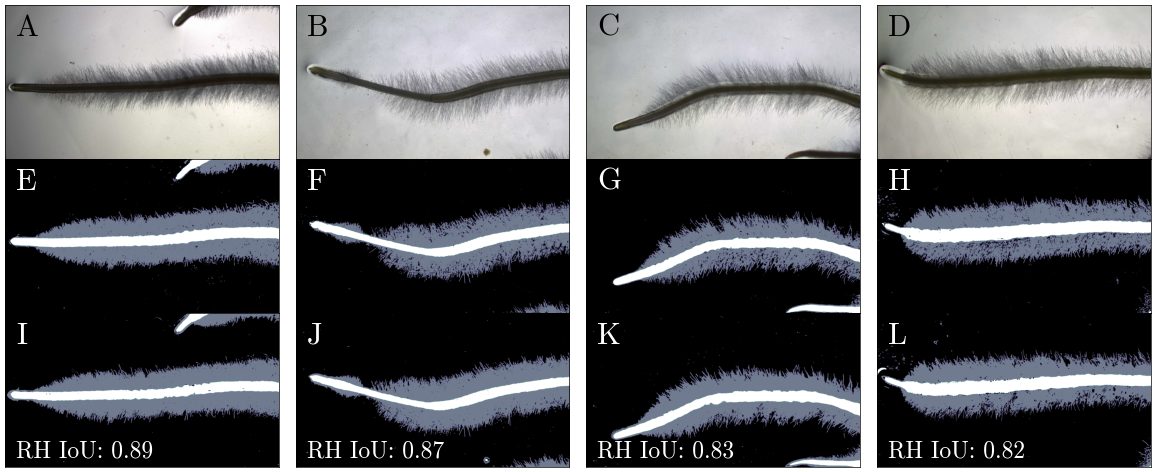

In [81]:
def plot_segmentation():
    # model segmentation masks
    mask_1 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/brompton_0007_predicted.png')
    mask_2 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/copain_0004_predicted.png')
    mask_3 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/flamingo_0008_predicted.png')
    mask_4 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/kloka_0008_predicted.png')

    # original images
    raw_1 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/brompton_0007.png')
    raw_2 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/copain_0004.png')
    raw_3 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/flamingo_0008.png')
    raw_4 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/kloka_0008.png')

    # manually annotated ground truths using ilastik
    gt_1 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/brompton_0007_Simple Segmentation_.png')
    gt_2 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/copain_0004_Simple Segmentation_.png')
    gt_3 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/flamingo_0008_Simple Segmentation_.png')
    gt_4 = iio.imread('/home/iantsang/pyRootHair/paper_data/S_Figure_4/kloka_0008_Simple Segmentation_.png')

    # convert ilastik labels from [1,2,3] to [0,1,2]
    def convert_mask(mask):
        newmask = mask.copy()
        newmask[mask == 1] = 0
        newmask[mask ==2] = 1
        newmask[mask ==3] = 2

        mask = newmask
        return mask

    # calculate intersection over union scores
    def calculate_class_iou(predicted, truth, px_class):
        predicted_subset = predicted == px_class
        truth_subset = truth == px_class
        intersection = np.logical_and(predicted_subset, truth_subset).sum()
        union = np.logical_or(predicted_subset, truth_subset).sum()

        return intersection / union

    # get IOUs for root hair region (class = 1)
    rh_iou_1 = calculate_class_iou(mask_1, convert_mask(gt_1), 1)
    rh_iou_2 = calculate_class_iou(mask_2, convert_mask(gt_2), 1)
    rh_iou_3 = calculate_class_iou(mask_3, convert_mask(gt_3), 1)
    rh_iou_4 = calculate_class_iou(mask_4, convert_mask(gt_4), 1)
    
    # create figure
    _, ax = plt.subplots(ncols=4, nrows=3, figsize=(15,6))
    plt.subplots_adjust(wspace=0,hspace=0)
    ax[0,0].imshow(np.rot90(raw_1, k=3)) # raw images
    ax[0,1].imshow(np.rot90(raw_2, k=3))
    ax[0,2].imshow(np.rot90(raw_3, k=3))
    ax[0,3].imshow(np.rot90(raw_4, k=3))

    ax[1,0].imshow(np.rot90(gt_1, k=3), cmap='bone') # ground truths
    ax[1,1].imshow(np.rot90(gt_2, k=3), cmap='bone')
    ax[1,2].imshow(np.rot90(gt_3, k=3), cmap='bone')
    ax[1,3].imshow(np.rot90(gt_4, k=3), cmap='bone')

    ax[2,0].imshow(np.rot90(mask_1, k=3), cmap='bone') # predicted segmentation masks
    ax[2,1].imshow(np.rot90(mask_2, k=3), cmap='bone')
    ax[2,2].imshow(np.rot90(mask_3, k=3), cmap='bone')
    ax[2,3].imshow(np.rot90(mask_4, k=3), cmap='bone')

    for axs in ax.reshape(-1):
        axs.set_xticklabels([])
        axs.set_yticklabels([])
        axs.set_xticks([])
        axs.set_yticks([])

    ax[2,0].annotate(f'RH IoU: {rh_iou_1:.2f}', xy=(0.04, 0.06), xycoords='axes fraction', color='white', fontsize=17)
    ax[2,1].annotate(f'RH IoU: {rh_iou_2:.2f}', xy=(0.04, 0.06), xycoords='axes fraction', color='white', fontsize=17)
    ax[2,2].annotate(f'RH IoU: {rh_iou_3:.2f}', xy=(0.04, 0.06), xycoords='axes fraction', color='white', fontsize=17)
    ax[2,3].annotate(f'RH IoU: {rh_iou_4:.2f}', xy=(0.04, 0.06), xycoords='axes fraction', color='white', fontsize=17)

    labs = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']

    for ax, lab in zip(ax.flat, labs):
        if lab not in ['A', 'B', 'C', 'D']:
            ax.annotate(lab, xy=(0.04, 0.8), xycoords='axes fraction', fontsize=22, color='white')
        else:
            ax.annotate(lab, xy=(0.04, 0.8), xycoords='axes fraction', fontsize=22, color='black')

plot_segmentation()

### Supplementary Figure 6 - Model History

In [85]:
def parse_training_log() -> pd.DataFrame: # training log as 'checkpoint' file from nnUNet training
    # read in file and parse
    with open('/home/iantsang/pyRootHair/paper_data/S_Figure_6/nnunet_training_log.txt') as file:
        content = file.readlines()
        content = [i.split(':')[-1].strip(' ').rstrip() for i in content]
        
        # separate each epoch's fields into a sublist
        sublists = []
        blanks = []
        
        for i in content:
            if i == '':
                if blanks:
                    sublists.append(blanks)
                    blanks = []
            else:
                blanks.append(i)
            
        sublists.append(blanks)
        
        dict_list = []
        
        # extract fields from sublists 
        for i in sublists:
            rowdict = {}
            rowdict['Epoch'] = int(i[0].split(' ')[-1])
            rowdict['lr'] = float(i[1])
            rowdict['train_loss'] = float(i[2].split(' ')[-1])
            rowdict['val_loss'] = float(i[3].split(' ')[-1])
            pseudo_root_dice = float(i[4].split('[')[-1].split(']')[0].split(',')[0].replace("np.float32(", "").replace(")",""))
            pseudo_rh_dice = float(i[4].split('[')[-1].split(']')[0].split(',')[1].replace("np.float32(", "").replace(")",""))
            rowdict['pseudo_dice'] = (pseudo_root_dice + pseudo_rh_dice) / 2
            rowdict['time'] = float(i[5].split(' ')[0])
            dict_list.append(rowdict)
        
        return pd.DataFrame.from_dict(dict_list)
    
training_df = parse_training_log()

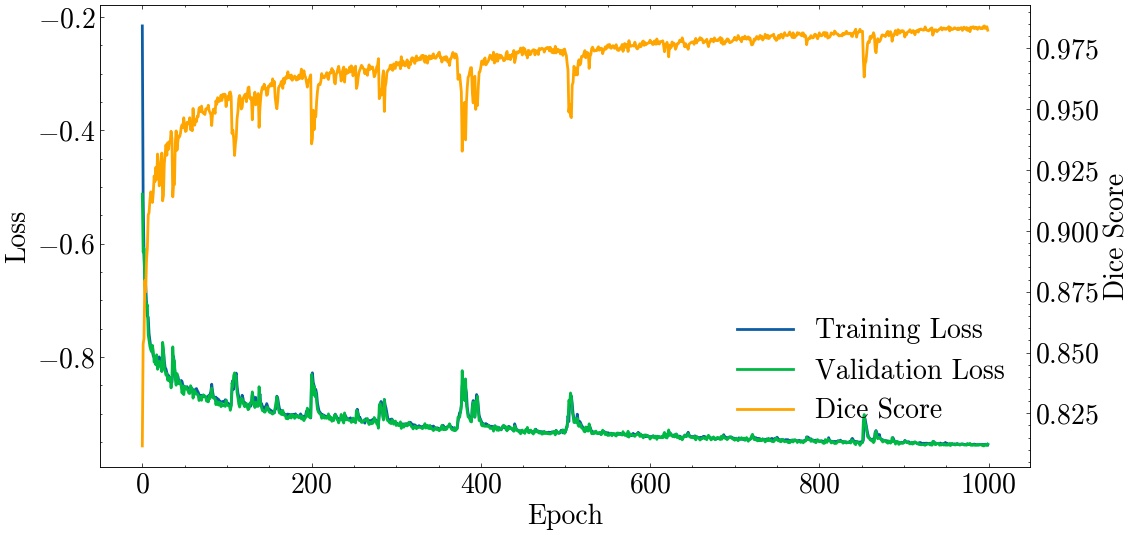

In [87]:
def plot_history():
    fig, ax1 = plt.subplots(figsize=(12,6))
    ax1.plot(training_df['Epoch'], training_df['train_loss'], label='Training Loss', lw=2)
    ax1.plot(training_df['Epoch'], training_df['val_loss'], label='Validation Loss', lw=2)
    ax2 = ax1.twinx()
    ax2.plot(training_df['Epoch'], training_df['pseudo_dice'], label='Dice Score', lw=2, color='orange')
    ax1.set_ylabel('Loss')
    ax2.set_ylabel('Dice Score')
    ax1.set_xlabel('Epoch')
    fig.legend(bbox_to_anchor=(0.9,0.4))

plot_history()

### Supplementary Figure 7 - Validation Metrics

In [92]:
def parse_summary() -> Tuple[pd.DataFrame, list, list]:
    with open('/home/iantsang/pyRootHair/paper_data/S_Figure_7/summary.json', 'r') as file:
        data = json.load(file)
        
    # extract dice and IOU scores from json file
    root_dices, root_ious = [],[]
    rh_dices, rh_ious = [],[]
    
    for idx, _ in enumerate(data['metric_per_case']):
        root_segmentation_params = data['metric_per_case'][idx]['metrics']['1']
        rh_segmentation_params = data['metric_per_case'][idx]['metrics']['2']

        root_dice, root_iou = root_segmentation_params['Dice'], root_segmentation_params['IoU']
        rh_dice, rh_iou = rh_segmentation_params['Dice'], rh_segmentation_params['IoU']
        root_dices.append(root_dice)
        root_ious.append(root_iou)
        rh_dices.append(rh_dice)
        rh_ious.append(rh_iou)
    
    # store as df 
    valid_scores_df = pd.DataFrame({'Root Dice': root_dices,
                                'Root IOU':root_ious,
                                'Root Hair Dice':rh_dices,
                                'Root Hair IOU':rh_ious})
    
    # calculate confusion matrix
    root = data['mean']['1']
    root_tp, root_fp, root_fn, root_tn = root['TP'], root['FP'], root['FN'], root['TN']

    root_cm = [[root_tp, root_fp],
            [root_fn, root_tn]]

    rh = data['mean']['2']
    rh_tp, rh_fp, rh_fn, rh_tn = rh['TP'], rh['FP'], rh['FN'], rh['TN']

    rh_cm = [[rh_tp, rh_fp],
            [rh_fn, rh_tn]]
    
    return valid_scores_df, root_cm, rh_cm

df, root_cm, rh_cm = parse_summary()

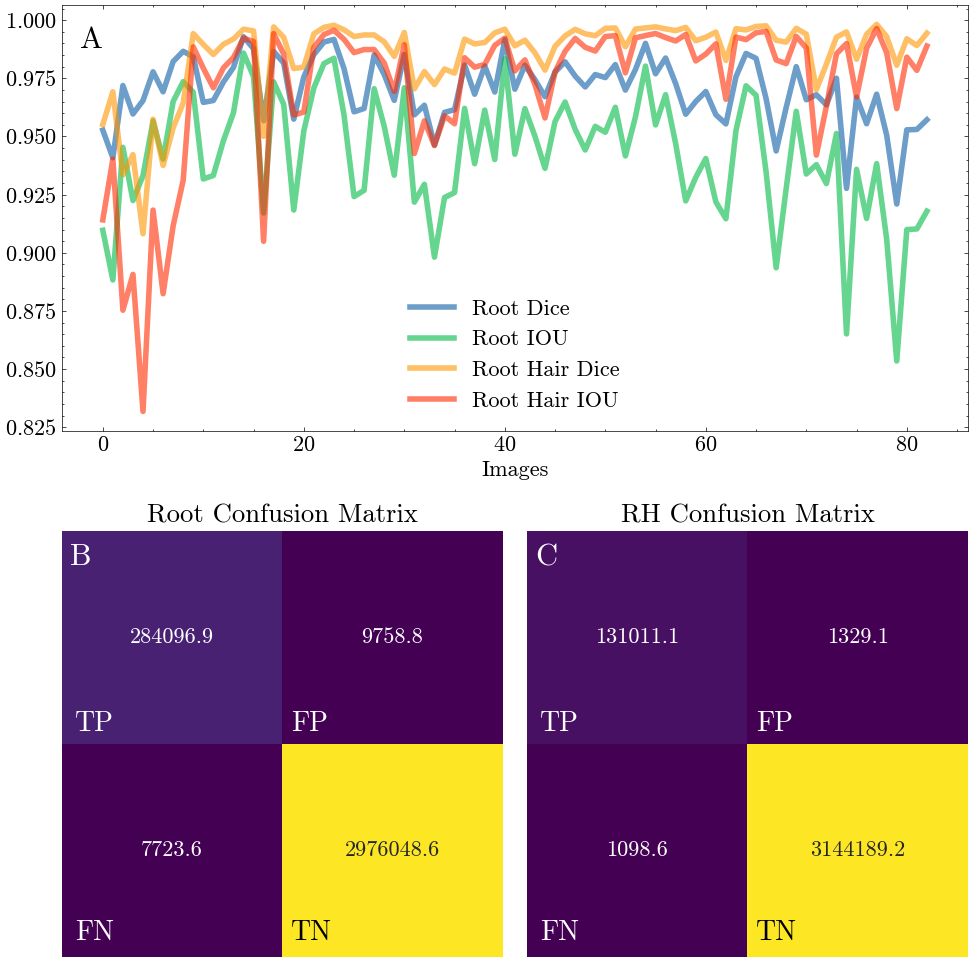

In [93]:
def plot_cms():
    plt.rcParams['font.size'] = 16
    _ = plt.figure(figsize=(10,10))
    ax1 = plt.subplot2grid((2,2),(0,0),colspan=2)
    ax2 = plt.subplot2grid((2,2),(1,0))
    ax3 = plt.subplot2grid((2,2),(1,1))

    # dice and ious
    df.plot(linewidth=4, alpha=0.6, ax=ax1)
    ax1.set_xlabel('Images')
    ax1.annotate('A', xy=(0.02,0.9), xycoords='axes fraction', fontsize=22, fontweight='bold')
    
    # root CM
    sns.heatmap(root_cm, annot=True, cmap='viridis', ax=ax2, fmt='.1f', cbar=False)
    ax2.set_title('Root Confusion Matrix')
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.annotate('B', xy=(0.02,0.92), xycoords='axes fraction', fontsize=22, fontweight='bold', color='white')
    ax2.annotate('TP', xy=(0.03,0.53), xycoords='axes fraction', fontsize=20, fontweight='bold', color='white')
    ax2.annotate('FP', xy=(0.52,0.53), xycoords='axes fraction', fontsize=20, fontweight='bold', color='white')
    ax2.annotate('FN', xy=(0.03,0.04), xycoords='axes fraction', fontsize=20, fontweight='bold', color='white')
    ax2.annotate('TN', xy=(0.52,0.04), xycoords='axes fraction', fontsize=20, fontweight='bold', color='black')
    
    # root hair CM
    sns.heatmap(rh_cm, annot=True, cmap='viridis', ax=ax3, fmt='.1f', cbar=False)
    ax3.set_title('RH Confusion Matrix')
    ax3.set_xticklabels([])
    ax3.set_yticklabels([])
    ax3.set_xticks([])
    ax3.set_yticks([])
    ax3.annotate('C', xy=(0.02,0.92), xycoords='axes fraction', fontsize=22, fontweight='bold', color='white')
    ax3.annotate('TP', xy=(0.03,0.53), xycoords='axes fraction', fontsize=20, fontweight='bold', color='white')
    ax3.annotate('FP', xy=(0.52,0.53), xycoords='axes fraction', fontsize=20, fontweight='bold', color='white')
    ax3.annotate('FN', xy=(0.03,0.04), xycoords='axes fraction', fontsize=20, fontweight='bold', color='white')
    ax3.annotate('TN', xy=(0.52,0.04), xycoords='axes fraction', fontsize=20, fontweight='bold', color='black')
    
    plt.tight_layout()

plot_cms()